In [2]:
import pandas as pd
import geopandas as gpd
import missingno
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy.integrate import simps
import sys
from sklearn.metrics.pairwise import euclidean_distances

sys.path.insert(0, "../../Modules")

from utils import *

enc = 'utf-8' 
dec = 'greek8'

In [3]:
raw_data = pd.read_csv('../data/GR_WNV_cases_GRID_2010-2021_original.csv', encoding = enc)
raw_data.head(5)

,αα,Id διαχείρισης δεδομένων,Έτος,Ηλικία \n(σε έτη),Φύλο,Ημ/νία έναρξης συμπτωμάτων,Προσβολή ΚΝΣ (ΝΑΙ/ΟΧΙ),Περιφέρεια πιθανής έκθεσης,Περιφερειακή ενότητα πιθανής έκθεσης,Δήμος πιθανής έκθεσης,Πόλη/χωριό (/συνοικία Αθήνας) πιθανής έκθεσης,Κωδικός κανάβου κελιού 1x1 χλμ πιθανής έκθεσης,Unnamed: 12,Unnamed: 13
0,1.0,3.0,2010.0,75,ΘΗΛΥ,28-07-10,NAI,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Θεσσαλονίκης,"Παπάφη, Θεσσαλονίκη",DW307,NaN,NaN
1,2.0,17.0,2010.0,78,ΑΡΡΕΝ,22-07-10,NAI,Κεντρικής Μακεδονίας,Ημαθίας,Βέροιας,Βέροια,EI242,NaN,NaN
2,3.0,4.0,2010.0,70,ΘΗΛΥ,24-07-10,NAI,Κεντρικής Μακεδονίας,Κιλκίς,Κιλκίς,Λεβεντοχώρι,CN297,NaN,NaN
3,4.0,21.0,2010.0,74,ΑΡΡΕΝ,30-7-2010,NAI,Κεντρικής Μακεδονίας,Κιλκίς,Κιλκίς,Καμπάνη,CU305,NaN,NaN
4,5.0,59.0,2010.0,19,ΘΗΛΥ,06-07-10,NAI,Κεντρικής Μακεδονίας,Σερρών,Ηράκλειας,Ποντισμένο,BL336,NaN,NaN


In [4]:
raw_data.shape

(1421, 14)

In [5]:
dataset = raw_data.set_axis(['idx', 'id', 'year', 'age', 'sex', 'onset of symptoms', 'cns attack', 'nuts2', 'nuts3', 'lau1', 'lau2', 'cell_code', 'unnamed1', 'unnamed2'], axis=1)

In [6]:
dataset.drop(columns = ['idx', 'id', 'cns attack', 'unnamed1', 'unnamed2'], inplace = True)
dataset.dropna(axis = 0, subset = ['onset of symptoms', 'lau1', 'cell_code'], how = 'any', inplace = True)
dataset['onset of symptoms'] = dataset['onset of symptoms'].apply(lambda x : x.replace("~", ""))
dataset = dataset[dataset['onset of symptoms'] != 'Άγνωστη']
dataset = dataset[dataset['nuts2'] != 'Άγνωστη']
dataset = dataset[dataset['nuts2'] != 'Απροσδιόριστη']
dataset = dataset[dataset['nuts2'] != 'Απροσδιόριστη (Ανατολικής Μακεδονίας & Θράκης Ή Κεντρικής Μακεδονίας)']
dataset['onset of symptoms'] = pd.to_datetime(dataset['onset of symptoms'], dayfirst=True, errors='coerce')
dataset['cases'] = 1
dataset = dataset.astype({"year":'int'})
dataset.head(5)

C:\Users\dimit\AppData\Local\Temp\ipykernel_96432\42650934.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset['onset of symptoms'] = pd.to_datetime(dataset['onset of symptoms'], dayfirst=True, errors='coerce')


,year,age,sex,onset of symptoms,nuts2,nuts3,lau1,lau2,cell_code,cases
0,2010,75,ΘΗΛΥ,2010-07-28,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Θεσσαλονίκης,"Παπάφη, Θεσσαλονίκη",DW307,1
1,2010,78,ΑΡΡΕΝ,2010-07-22,Κεντρικής Μακεδονίας,Ημαθίας,Βέροιας,Βέροια,EI242,1
2,2010,70,ΘΗΛΥ,2010-07-24,Κεντρικής Μακεδονίας,Κιλκίς,Κιλκίς,Λεβεντοχώρι,CN297,1
3,2010,74,ΑΡΡΕΝ,2010-07-30,Κεντρικής Μακεδονίας,Κιλκίς,Κιλκίς,Καμπάνη,CU305,1
4,2010,19,ΘΗΛΥ,2010-07-06,Κεντρικής Μακεδονίας,Σερρών,Ηράκλειας,Ποντισμένο,BL336,1


In [7]:
dataset.shape

(1386, 10)

In [8]:
df_missign = describe_dataframe(dataset)

df_missign

,Column,Missing
0,year,0.0000
1,age,0.0000
2,sex,0.0000
3,onset of symptoms,0.4329
4,nuts2,0.0000
5,nuts3,0.0000
6,lau1,0.0000
7,lau2,0.0000
8,cell_code,0.0000
9,cases,0.0000


In [9]:
dataset.dropna(axis = 0, subset = ['onset of symptoms'], how = 'any', inplace = True)
dataset.reset_index(drop=True, inplace = True)

In [10]:
dataset

,year,age,sex,onset of symptoms,nuts2,nuts3,lau1,lau2,cell_code,cases
0,2010,75,ΘΗΛΥ,2010-07-28,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Θεσσαλονίκης,"Παπάφη, Θεσσαλονίκη",DW307,1
1,2010,78,ΑΡΡΕΝ,2010-07-22,Κεντρικής Μακεδονίας,Ημαθίας,Βέροιας,Βέροια,EI242,1
2,2010,70,ΘΗΛΥ,2010-07-24,Κεντρικής Μακεδονίας,Κιλκίς,Κιλκίς,Λεβεντοχώρι,CN297,1
3,2010,74,ΑΡΡΕΝ,2010-07-30,Κεντρικής Μακεδονίας,Κιλκίς,Κιλκίς,Καμπάνη,CU305,1
4,2010,19,ΘΗΛΥ,2010-07-06,Κεντρικής Μακεδονίας,Σερρών,Ηράκλειας,Ποντισμένο,BL336,1
...,...,...,...,...,...,...,...,...,...,...
1375,2021,46,ΑΡΡΕΝ,2021-08-31,Ανατολικής Μακεδονίας & Θράκης,Καβάλας,Παγγαίου,Παραλία Οφρυνίου (Τούζλα),DH387,1
1376,2021,85,ΑΡΡΕΝ,2021-09-13,Κεντρικής Μακεδονίας,Ημαθίας,Ηρωικής πόλης Νάουσας,Αγγελοχώρι,DQ244,1
1377,2021,52,ΘΗΛΥ,2021-09-03,Κεντρικής Μακεδονίας,Ημαθίας,Αλεξάνδρειας,Πλατύ,DU272,1
1378,2021,65,ΑΡΡΕΝ,2021-10-04,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Θερμαϊκού,Περαία,EK305,1


In [11]:
nuts2 = dataset['nuts2'].drop_duplicates().sort_values().tolist()
nuts3 = dataset['nuts3'].drop_duplicates().sort_values().tolist()
lau1 = dataset['lau1'].drop_duplicates().sort_values().tolist()
lau2 = dataset['lau2'].drop_duplicates().sort_values().tolist()

<Axes: >

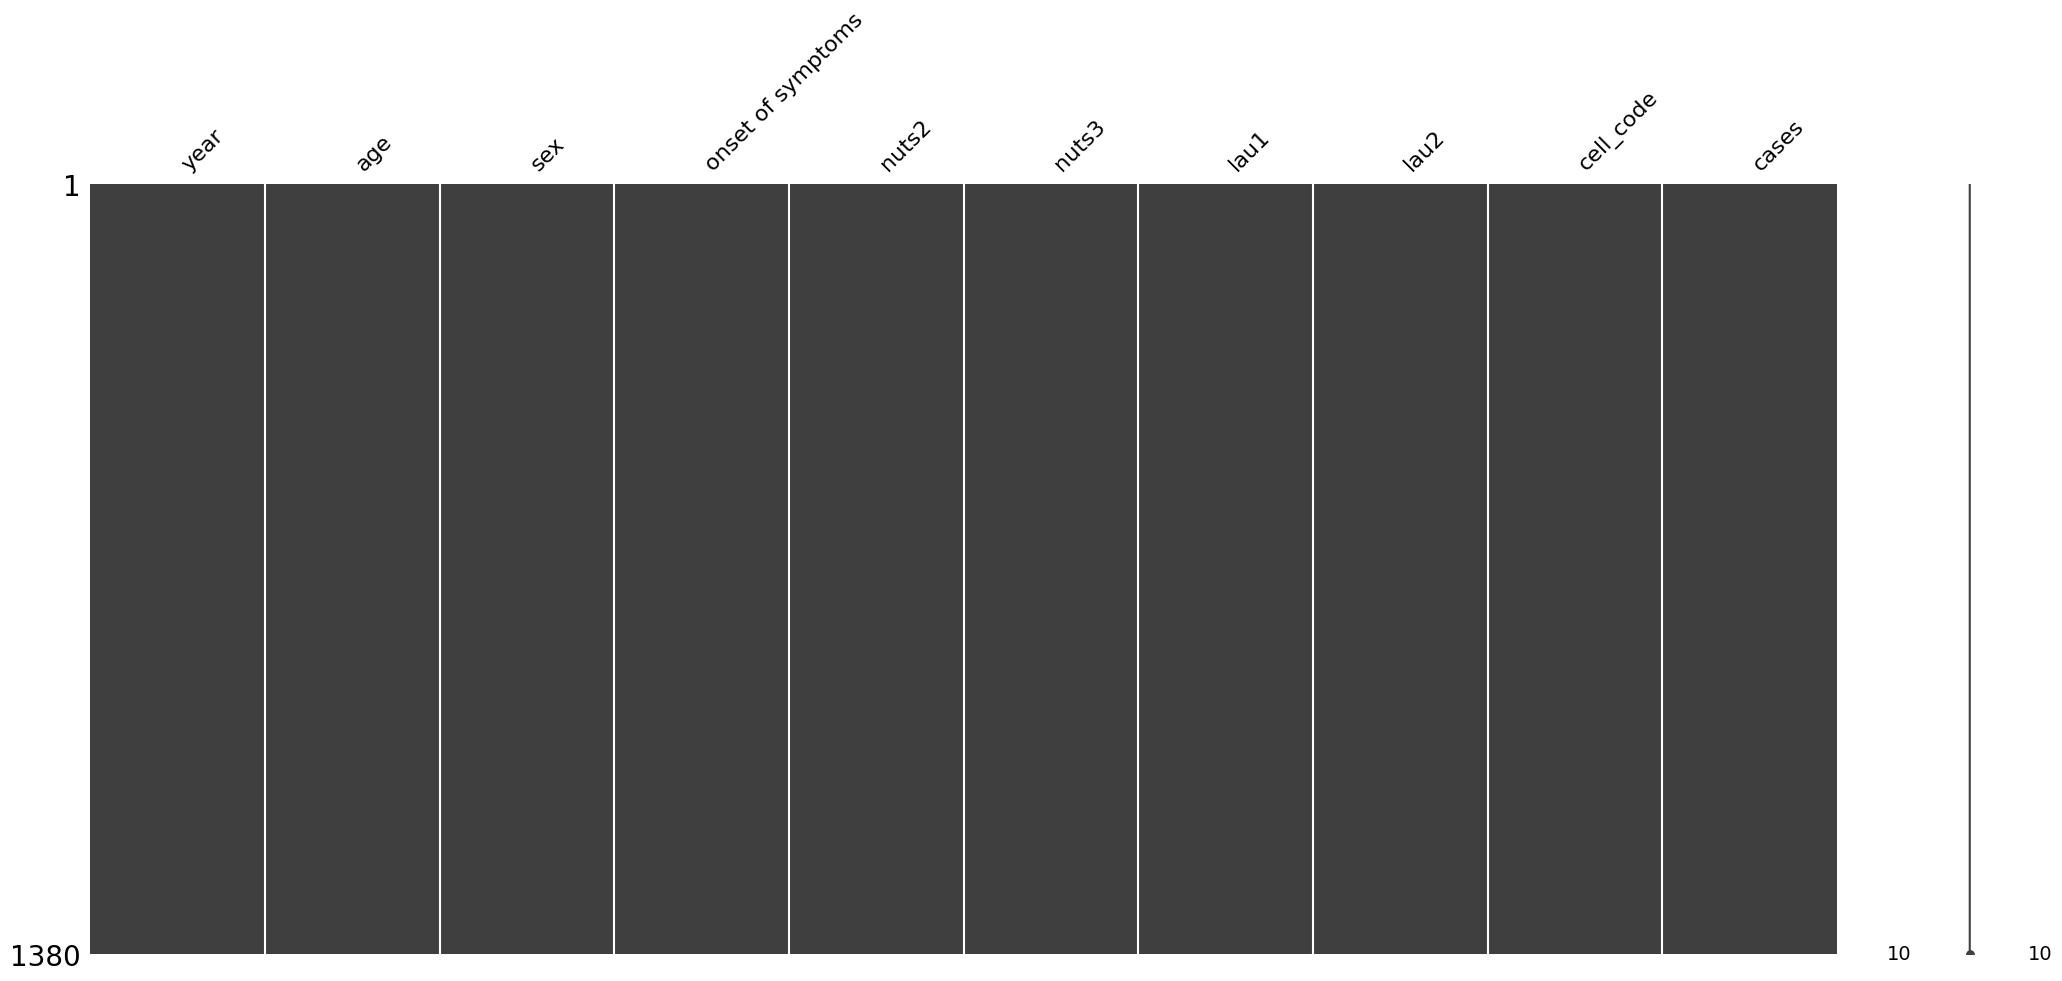

In [12]:
missingno.matrix(dataset)

In [13]:
process_greek(dataset, 'nuts2')
process_greek(dataset, 'nuts3')
process_greek(dataset, 'lau1')
process_greek(dataset, 'lau2')

In [14]:
dataset

,year,age,sex,onset of symptoms,nuts2,nuts3,lau1,lau2,cell_code,cases
0,2010,75,ΘΗΛΥ,2010-07-28,κεντρικης μακεδονιας,θεσσαλονικης,θεσσαλονικης,"παπαφη, θεσσαλονικη",DW307,1
1,2010,78,ΑΡΡΕΝ,2010-07-22,κεντρικης μακεδονιας,ημαθιας,βεροιας,βεροια,EI242,1
2,2010,70,ΘΗΛΥ,2010-07-24,κεντρικης μακεδονιας,κιλκις,κιλκις,λεβεντοχωρι,CN297,1
3,2010,74,ΑΡΡΕΝ,2010-07-30,κεντρικης μακεδονιας,κιλκις,κιλκις,καμπανη,CU305,1
4,2010,19,ΘΗΛΥ,2010-07-06,κεντρικης μακεδονιας,σερρων,ηρακλειας,ποντισμενο,BL336,1
...,...,...,...,...,...,...,...,...,...,...
1375,2021,46,ΑΡΡΕΝ,2021-08-31,ανατολικης μακεδονιας και θρακης,καβαλας,παγγαιου,παραλια οφρυνιου (τουζλα),DH387,1
1376,2021,85,ΑΡΡΕΝ,2021-09-13,κεντρικης μακεδονιας,ημαθιας,ηρωικης πολης ναουσας,αγγελοχωρι,DQ244,1
1377,2021,52,ΘΗΛΥ,2021-09-03,κεντρικης μακεδονιας,ημαθιας,αλεξανδρειας,πλατυ,DU272,1
1378,2021,65,ΑΡΡΕΝ,2021-10-04,κεντρικης μακεδονιας,θεσσαλονικης,θερμαικου,περαια,EK305,1


In [15]:
dataset['day'] = dataset['onset of symptoms'].apply(lambda x : x.day)
dataset['month'] = dataset['onset of symptoms'].apply(lambda x : x.month)
dataset['year'] = dataset['onset of symptoms'].apply(lambda x : x.year)

In [16]:
nuts2_processed = dataset['nuts2'].drop_duplicates().sort_values().tolist()
nuts3_processed = dataset['nuts3'].drop_duplicates().sort_values().tolist()
lau1_processed = dataset['lau1'].drop_duplicates().sort_values().tolist()
lau2_processed = dataset['lau2'].drop_duplicates().sort_values().tolist()

In [17]:
dataset

,year,age,sex,onset of symptoms,nuts2,nuts3,lau1,lau2,cell_code,cases,day,month
0,2010,75,ΘΗΛΥ,2010-07-28,κεντρικης μακεδονιας,θεσσαλονικης,θεσσαλονικης,"παπαφη, θεσσαλονικη",DW307,1,28,7
1,2010,78,ΑΡΡΕΝ,2010-07-22,κεντρικης μακεδονιας,ημαθιας,βεροιας,βεροια,EI242,1,22,7
2,2010,70,ΘΗΛΥ,2010-07-24,κεντρικης μακεδονιας,κιλκις,κιλκις,λεβεντοχωρι,CN297,1,24,7
3,2010,74,ΑΡΡΕΝ,2010-07-30,κεντρικης μακεδονιας,κιλκις,κιλκις,καμπανη,CU305,1,30,7
4,2010,19,ΘΗΛΥ,2010-07-06,κεντρικης μακεδονιας,σερρων,ηρακλειας,ποντισμενο,BL336,1,6,7
...,...,...,...,...,...,...,...,...,...,...,...,...
1375,2021,46,ΑΡΡΕΝ,2021-08-31,ανατολικης μακεδονιας και θρακης,καβαλας,παγγαιου,παραλια οφρυνιου (τουζλα),DH387,1,31,8
1376,2021,85,ΑΡΡΕΝ,2021-09-13,κεντρικης μακεδονιας,ημαθιας,ηρωικης πολης ναουσας,αγγελοχωρι,DQ244,1,13,9
1377,2021,52,ΘΗΛΥ,2021-09-03,κεντρικης μακεδονιας,ημαθιας,αλεξανδρειας,πλατυ,DU272,1,3,9
1378,2021,65,ΑΡΡΕΝ,2021-10-04,κεντρικης μακεδονιας,θεσσαλονικης,θερμαικου,περαια,EK305,1,4,10


In [18]:
sexes = {'ΘΗΛΥ': 'f', 'ΑΡΡΕΝ': 'm'}
dataset['sex'] = dataset['sex'].map(sexes)  

In [19]:
dataset = dataset.reindex(columns=['age', 'sex', 'onset of symptoms', 'year', 'month', 'day', 'nuts2', 'nuts3', 'lau1', 'lau2', 'cell_code', 'cases'])

In [20]:
dataset.drop(columns=['age', 'sex'], inplace=True)

In [21]:
dataset

,onset of symptoms,year,month,day,nuts2,nuts3,lau1,lau2,cell_code,cases
0,2010-07-28,2010,7,28,κεντρικης μακεδονιας,θεσσαλονικης,θεσσαλονικης,"παπαφη, θεσσαλονικη",DW307,1
1,2010-07-22,2010,7,22,κεντρικης μακεδονιας,ημαθιας,βεροιας,βεροια,EI242,1
2,2010-07-24,2010,7,24,κεντρικης μακεδονιας,κιλκις,κιλκις,λεβεντοχωρι,CN297,1
3,2010-07-30,2010,7,30,κεντρικης μακεδονιας,κιλκις,κιλκις,καμπανη,CU305,1
4,2010-07-06,2010,7,6,κεντρικης μακεδονιας,σερρων,ηρακλειας,ποντισμενο,BL336,1
...,...,...,...,...,...,...,...,...,...,...
1375,2021-08-31,2021,8,31,ανατολικης μακεδονιας και θρακης,καβαλας,παγγαιου,παραλια οφρυνιου (τουζλα),DH387,1
1376,2021-09-13,2021,9,13,κεντρικης μακεδονιας,ημαθιας,ηρωικης πολης ναουσας,αγγελοχωρι,DQ244,1
1377,2021-09-03,2021,9,3,κεντρικης μακεδονιας,ημαθιας,αλεξανδρειας,πλατυ,DU272,1
1378,2021-10-04,2021,10,4,κεντρικης μακεδονιας,θεσσαλονικης,θερμαικου,περαια,EK305,1


In [22]:
dataset.cases.unique()

array([1], dtype=int64)

In [23]:
data_grouped = dataset.groupby(['onset of symptoms','year','month','day','nuts2','nuts3','lau1','lau2','cell_code'], as_index = False)
dataset = data_grouped.sum()

In [24]:
dataset.cases.unique()

array([1, 2], dtype=int64)

In [25]:
dataset

,onset of symptoms,year,month,day,nuts2,nuts3,lau1,lau2,cell_code,cases
0,2010-07-06,2010,7,6,κεντρικης μακεδονιας,σερρων,ηρακλειας,ποντισμενο,BL336,1
1,2010-07-16,2010,7,16,κεντρικης μακεδονιας,κιλκις,κιλκις,μεσοι αποστολοι,CS294,1
2,2010-07-18,2010,7,18,κεντρικης μακεδονιας,πελλας,πελλας,γιαννιτσα,DE262,1
3,2010-07-19,2010,7,19,κεντρικης μακεδονιας,θεσσαλονικης,καλαμαριας,καλαμαρια,EB307,1
4,2010-07-19,2010,7,19,κεντρικης μακεδονιας,θεσσαλονικης,καλαμαριας,καραμπουρνακι,EB308,1
...,...,...,...,...,...,...,...,...,...,...
1359,2021-09-13,2021,9,13,κεντρικης μακεδονιας,ημαθιας,ηρωικης πολης ναουσας,αγγελοχωρι,DQ244,1
1360,2021-09-15,2021,9,15,αττικης,ανατολικης αττικης,σπατων αρτεμιδος,αρτεμιδα,PG397,1
1361,2021-09-17,2021,9,17,κεντρικης μακεδονιας,ημαθιας,αλεξανδρειας,κλειδι,ED276,1
1362,2021-10-04,2021,10,4,κεντρικης μακεδονιας,θεσσαλονικης,θερμαικου,περαια,EK305,1


In [26]:
dataset.to_csv("../data/GR_WNV_cases_GRID_2010-2021_processed.csv", encoding = enc, index = False)

In [27]:
dataset = convert_multiple_cases(dataset, target_col = 'cases')

In [28]:
dataset

,onset of symptoms,year,month,day,nuts2,nuts3,lau1,lau2,cell_code,cases
0,2010-07-06,2010,7,6,κεντρικης μακεδονιας,σερρων,ηρακλειας,ποντισμενο,BL336,1
1,2010-07-16,2010,7,16,κεντρικης μακεδονιας,κιλκις,κιλκις,μεσοι αποστολοι,CS294,1
2,2010-07-18,2010,7,18,κεντρικης μακεδονιας,πελλας,πελλας,γιαννιτσα,DE262,1
3,2010-07-19,2010,7,19,κεντρικης μακεδονιας,θεσσαλονικης,καλαμαριας,καλαμαρια,EB307,1
4,2010-07-19,2010,7,19,κεντρικης μακεδονιας,θεσσαλονικης,καλαμαριας,καραμπουρνακι,EB308,1
...,...,...,...,...,...,...,...,...,...,...
1375,2018-08-04,2018,8,4,αττικης,πειραιως και νησων,νικαιας αγιου ιωαννη ρεντη,νικαια,PG365,1
1376,2018-08-17,2018,8,17,αττικης,πειραιως και νησων,νικαιας αγιου ιωαννη ρεντη,νικαια,PF365,1
1377,2018-09-13,2018,9,13,αττικης,δυτικου τομεα αθηνων,χαιδαριου,χαιδαρι,PC367,1
1378,2019-08-05,2019,8,5,ανατολικης μακεδονιας και θρακης,καβαλας,νεστου,ζαρκαδια,CG450,1


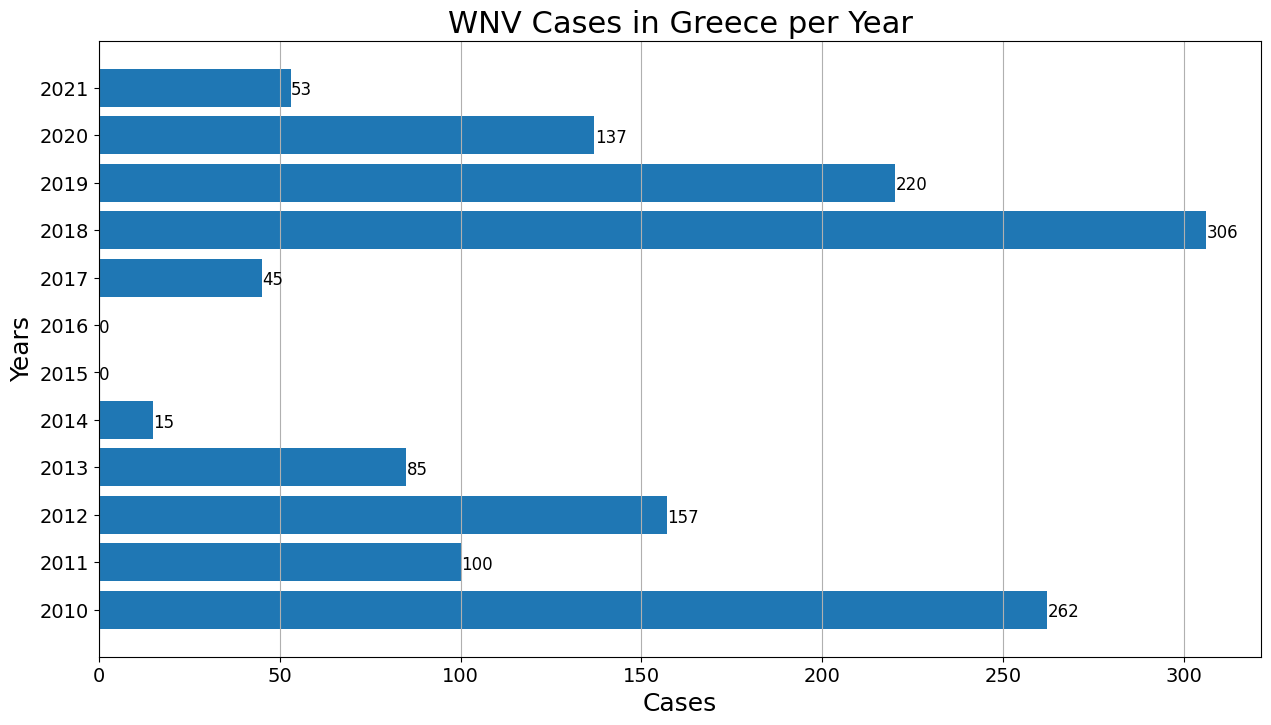

In [29]:
years = [year for year in range(2010, 2022)]
cases = [len(dataset.query(f"year == {year}")) for year in years]

plt.figure(num = None, figsize = (15,8), facecolor='w', edgecolor='b')
#plt.bar(years, cases)
plt.barh(years, cases)

#ax.bar_label(bars)
y_t = plt.xticks(np.arange(0, max(cases) + 10, step = 50), size = 14)
x_t = plt.yticks(np.arange(min(years), max(years) + 1, step = 1), size = 14)
x_l  = plt.ylabel('Years', size = 18)
y_l =  plt.xlabel('Cases', size = 18)
title = plt.title('WNV Cases in Greece per Year', size = 22)
for year, case in zip(years,cases):
    plt.text(case+0.15, year-0.15, str(case), size = 12)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()

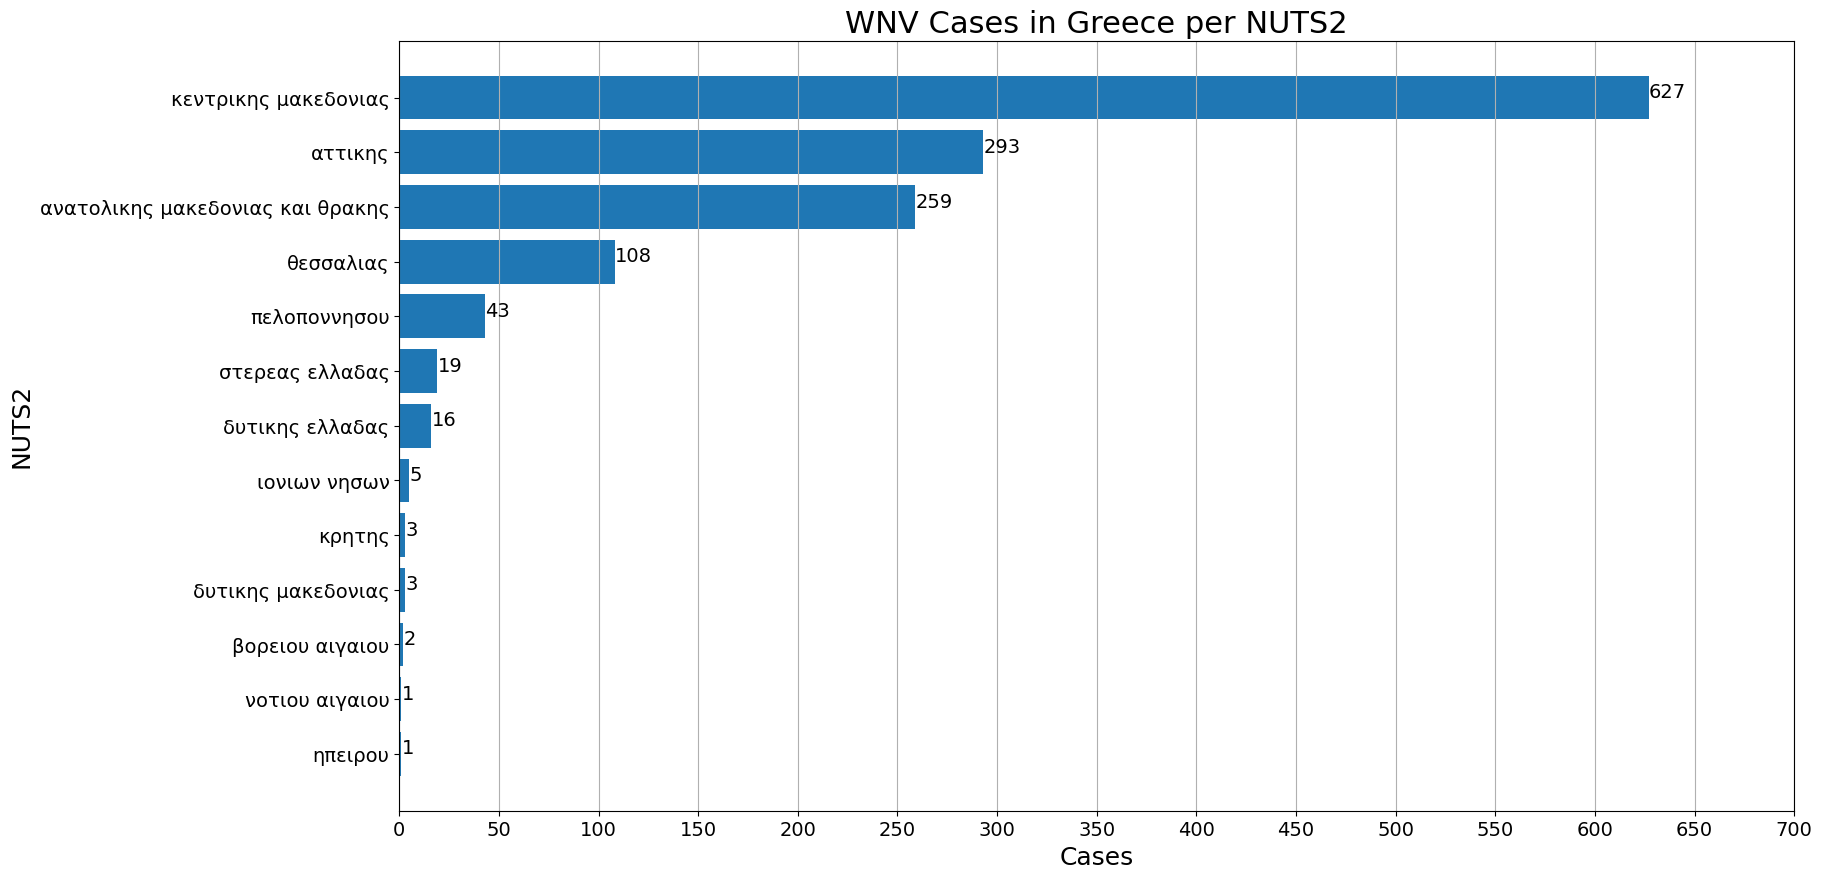

In [30]:
nuts2 = dataset['nuts2'].drop_duplicates().sort_values().tolist()
cases = [len(dataset.query(f"nuts2 == '{nuts2_unit}'")) for nuts2_unit in nuts2]

cases, nuts2 = zip(*sorted(zip(cases, nuts2)))

plt.figure(num = None, figsize = (18,10), facecolor='w', edgecolor='b')
plt.barh(nuts2, cases)

y_t = plt.xticks(np.arange(0, max(cases) + 100, step = 50), size = 14)
x_t = plt.yticks(nuts2, size = 14)
x_l  = plt.ylabel('NUTS2', size = 18)
y_l =  plt.xlabel('Cases', size = 18)
title = plt.title('WNV Cases in Greece per NUTS2', size = 22)
for nuts2, case in zip(nuts2,cases):
    plt.text(case+0.15, nuts2, str(case), size = 14)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()

In [31]:
nuts_2_IDS = {'αττικης': 'EL30', 
              'βορειου αιγαιου': 'EL41', 
              'νοτιου αιγαιου': 'EL42', 
              'κρητης': 'EL43', 
              'ανατολικης μακεδονιας και θρακης': 'EL51', 
              'κεντρικης μακεδονιας': 'EL52', 
              'δυτικης μακεδονιας': 'EL53', 
              'ηπειρου': 'EL54', 
              'θεσσαλιας': 'EL61', 
              'ιονιων νησων': 'EL62', 
              'δυτικης ελλαδας': 'EL63',
              'στερεας ελλαδας': 'EL64',
              'πελοποννησου': 'EL65'}

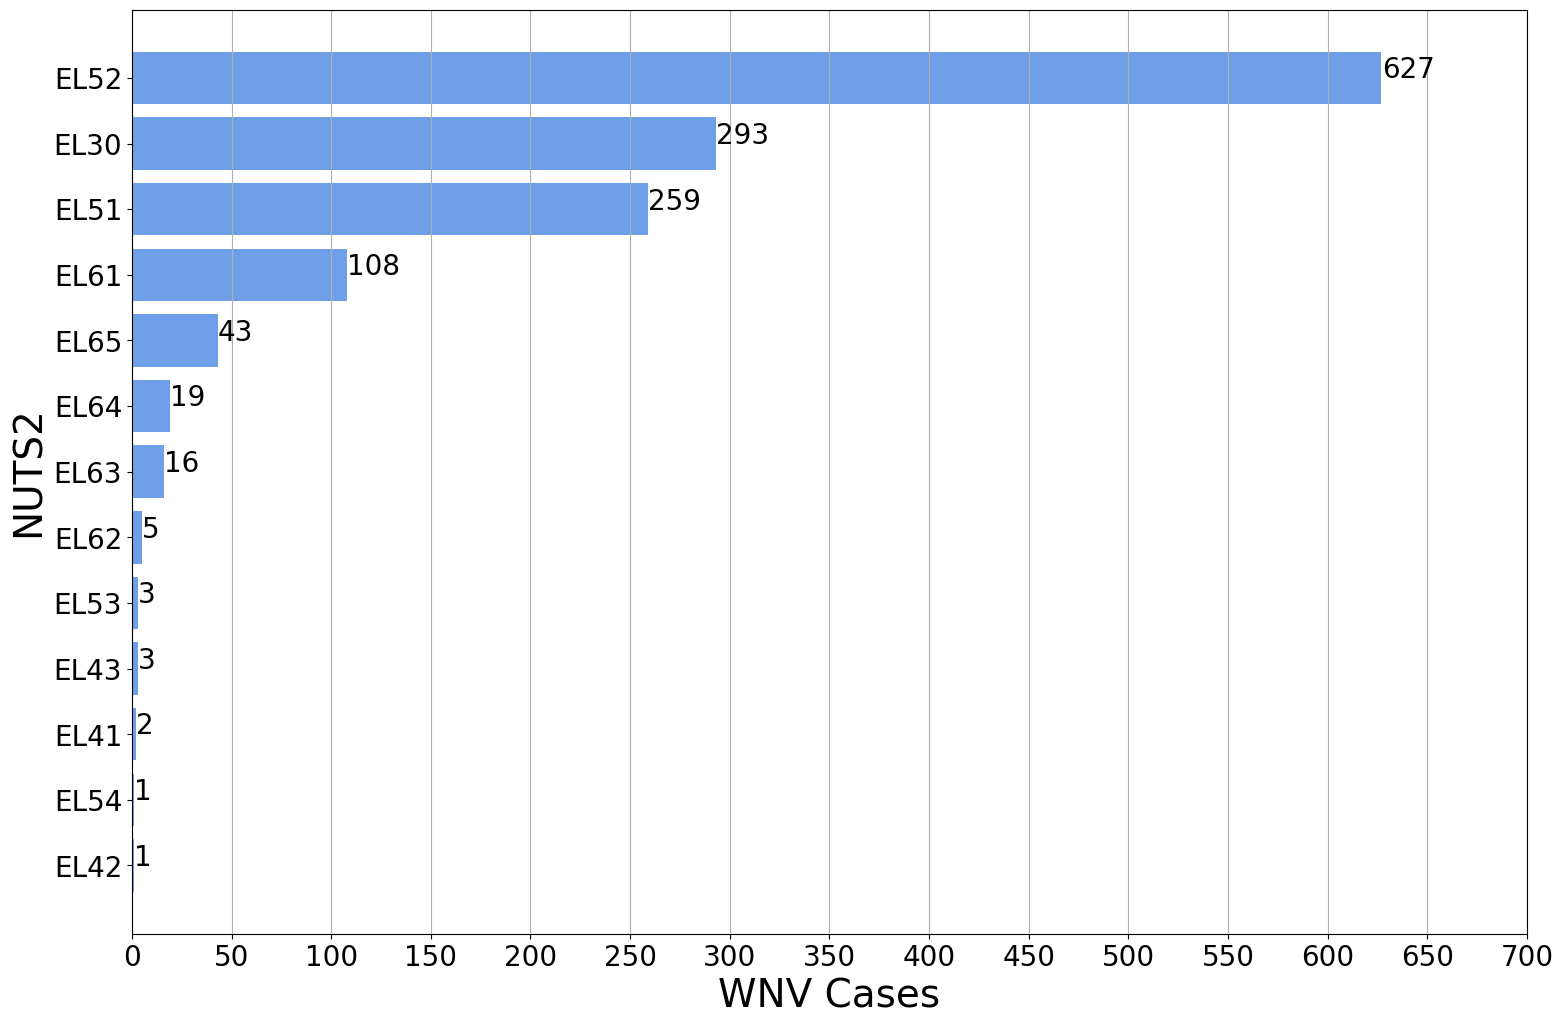

In [ ]:
nuts2 = dataset['nuts2'].drop_duplicates().sort_values().tolist()
cases = [len(dataset.query(f"nuts2 == '{nuts2_unit}'")) for nuts2_unit in nuts2]

nuts2_ids = [nuts_2_IDS[key] for key in nuts2 if key in nuts_2_IDS]

cases, nuts2_ids = zip(*sorted(zip(cases, nuts2_ids)))

plt.figure(num = None, figsize = (18,12), facecolor='w', edgecolor='b')
plt.barh(nuts2_ids, cases, color='#6f9fe9')

y_t = plt.xticks(np.arange(0, max(cases) + 100, step = 50), size = 20)
x_t = plt.yticks(nuts2_ids, size = 20)
x_l  = plt.ylabel('NUTS2', size = 28)
y_l =  plt.xlabel('WNV Cases', size = 28)
for nuts2_ids, case in zip(nuts2_ids,cases):
    plt.text(case+0.15, nuts2_ids, str(case), size = 20)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()

In [33]:
cases

(1, 1, 2, 3, 3, 5, 16, 19, 43, 108, 259, 293, 627)

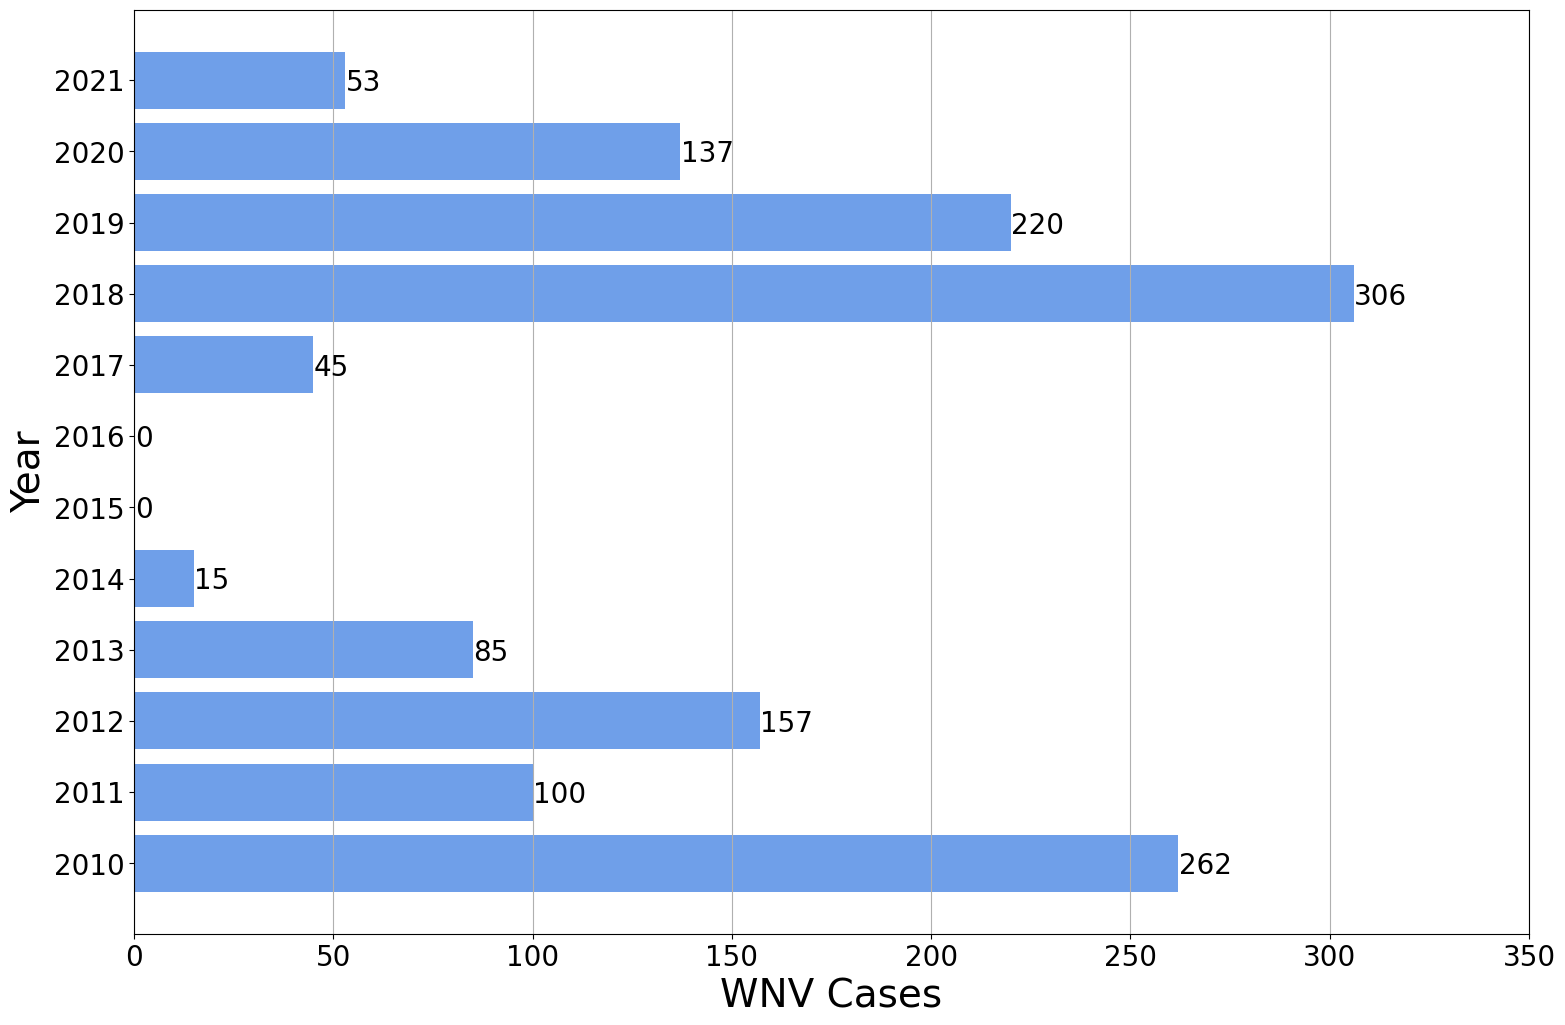

In [37]:
years = [year for year in range(2010, 2022)]
cases = [len(dataset.query(f"year == {year}")) for year in years]

plt.figure(num = None, figsize = (18,12), facecolor='w', edgecolor='b')
plt.barh(years, cases, color='#6f9fe9')

y_t = plt.xticks(np.arange(0, max(cases) + 50, step = 50), size = 20)
x_t = plt.yticks(np.arange(min(years), max(years) + 1, step = 1), size = 20)
x_l  = plt.ylabel('Year', size = 28)
y_l =  plt.xlabel('WNV Cases', size = 28)
for year, case in zip(years,cases):
    plt.text(case+0.15, year-0.15, str(case), size = 20)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()
###########################################################################################